# TabFM (zero-shot) vs CatBoost — F1 pit-stop prediction

Google's [TabFM](https://github.com/google-research/tabfm) is a 1.6B-parameter tabular foundation model
([blog](https://research.google/blog/introducing-tabfm-a-zero-shot-foundation-model-for-tabular-data/)):
it predicts via in-context learning, reading training rows as context in a single forward pass.
No training, no tuning, no feature engineering.

This experiment races it against CatBoost on the
[Kaggle Playground S6E5 pit-stop data](https://www.kaggle.com/competitions/playground-series-s6e5)
(predict whether an F1 driver pits next lap, ROC AUC). The data is synthetic and was generated in
May 2026, well after TabFM's training, so there is no contamination. My tuned CatBoost baseline with
heavy feature engineering lives in [`../kaggle-f1-pit-stops`](../kaggle-f1-pit-stops).

**Design** - identical `StratifiedKFold(5, seed=42)` protocol as the baseline; every model is scored
on the *same* fixed 5,000-row subsample of the fold-0 validation split.

| Experiment | Question |
|---|---|
| **A. Model x features grid** | Does zero-shot TabFM beat CatBoost on raw columns? Does feature engineering still help a foundation model? |
| **B. Context-size sweep** | How does TabFM scale with in-context rows, and when does training CatBoost start to win? |

All heavy lifting lives in [`experiment.py`](experiment.py), with each run cached to
`artifacts/runs/`; `run_all.py` precomputes everything (see README), so executing this notebook
on a warm cache takes seconds.

Hardware notes: TabFM's PyTorch backend runs on Apple Silicon via MPS (~17x faster than CPU here),
but the 1.6B model still means inference is *minutes* - wall-clock time is part of the result.
Its cost also scales roughly linearly with column count, so the engineered feature set
(104 columns vs 14 raw) gets a smaller context budget (2k rows vs 5k).

In [1]:
import experiment as ex

print(f'eval rows: {ex.N_EVAL:,} (fold {ex.FOLD} val subsample)')
print(f'TabFM context: raw {ex.N_CTX:,} rows, engineered {ex.N_CTX_FE:,} rows, '
      f'{ex.N_ESTIMATORS} ensemble members')
d = ex.data()

eval rows: 5,000 (fold 0 val subsample)
TabFM context: raw 5,000 rows, engineered 2,000 rows, 8 ensemble members


[13:45:25] data ready: raw (439140, 14), engineered (439140, 104) (2s)


## Experiment A - model x features grid

Raw = the 14 competition columns as-is. Engineered = the full baseline pipeline (`features.py`:
~100 lag/lead, stint, race-context and OOF-target-encoded features). CatBoost appears both
row-budget-matched to TabFM's context (isolates model quality at a fixed row budget) and trained
on the full fold-0 split (what you would actually deploy; tuned params for the engineered run).

In [2]:
grid = ex.grid_df()
grid.style.format({'auc': '{:.4f}', 'seconds': '{:,.0f}', 'train_rows': '{:,}'})

,model,features,train_rows,auc,seconds
0,TabFM,raw,"5,000",0.9400,374
1,TabFM,engineered,"2,000",0.9308,"5,557"
2,CatBoost,raw,"5,000",0.9151,1
3,CatBoost,engineered,"2,000",0.9045,3
4,CatBoost,raw,"351,312",0.9509,65
5,CatBoost,engineered,"351,312",0.9496,164


Matplotlib is building the font cache; this may take a moment.


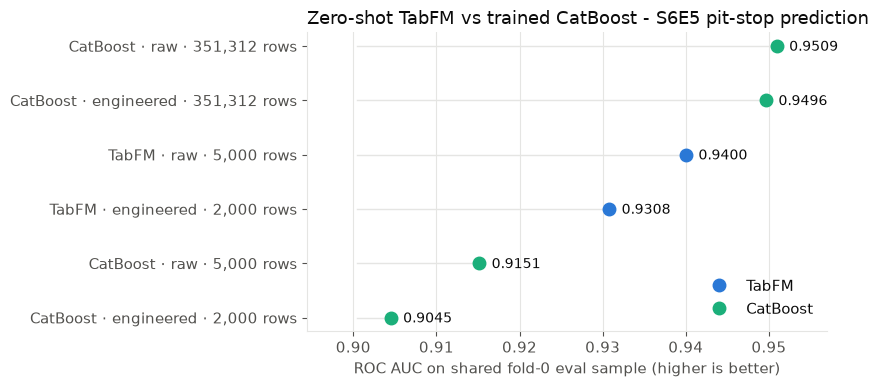

In [3]:
import matplotlib.pyplot as plt

BLUE, AQUA = '#2a78d6', '#1baf7a'          # TabFM / CatBoost - fixed entity colors
INK, INK2, GRID = '#0b0b0b', '#52514e', '#e5e5e3'
plt.rcParams.update({
    'figure.facecolor': 'white', 'axes.facecolor': 'white',
    'axes.edgecolor': GRID, 'axes.labelcolor': INK2,
    'text.color': INK, 'xtick.color': INK2, 'ytick.color': INK2,
    'axes.spines.top': False, 'axes.spines.right': False, 'font.size': 11,
})
COLOR = {'TabFM': BLUE, 'CatBoost': AQUA}

g = grid.copy()
g['label'] = g.apply(
    lambda r: f"{r['model']} · {r['features']} · {r['train_rows']:,} rows", axis=1)
g = g.sort_values('auc').reset_index(drop=True)

fig, ax = plt.subplots(figsize=(8.5, 4))
ax.set_axisbelow(True)
ax.grid(axis='x', color=GRID, linewidth=0.8)
for i, r in g.iterrows():
    ax.plot([g['auc'].min() - 0.004, r['auc']], [i, i], color=GRID, linewidth=1, zorder=1)
    ax.plot(r['auc'], i, 'o', markersize=9, color=COLOR[r['model']], zorder=3)
    ax.annotate(f"{r['auc']:.4f}", (r['auc'], i), textcoords='offset points',
                xytext=(9, -3.5), fontsize=10, color=INK)
ax.set_yticks(range(len(g)), g['label'])
ax.set_xlabel('ROC AUC on shared fold-0 eval sample (higher is better)')
ax.set_title('Zero-shot TabFM vs trained CatBoost - S6E5 pit-stop prediction', loc='left')
handles = [plt.Line2D([], [], marker='o', linestyle='', markersize=9, color=c, label=m)
           for m, c in COLOR.items()]
ax.legend(handles=handles, frameon=False, loc='lower right')
ax.margins(x=0.12)
plt.tight_layout()
plt.show()

## Experiment B - context-size sweep

TabFM and CatBoost each get the *same* n training rows (raw features only), scored on the same eval
sample. The dashed reference is CatBoost trained on the full fold (~351k rows). Second panel:
wall-clock cost - TabFM's "no training" still bills you at inference time.

In [4]:
sweep = ex.sweep_df()
sweep.pivot(index='n_rows', columns='model', values='auc').round(4)

model,CatBoost,TabFM
n_rows,,
500,0.8434,0.9139
1000,0.8956,0.9297
2000,0.9067,0.9336
5000,0.9151,0.9400
10000,0.9282,0.9435


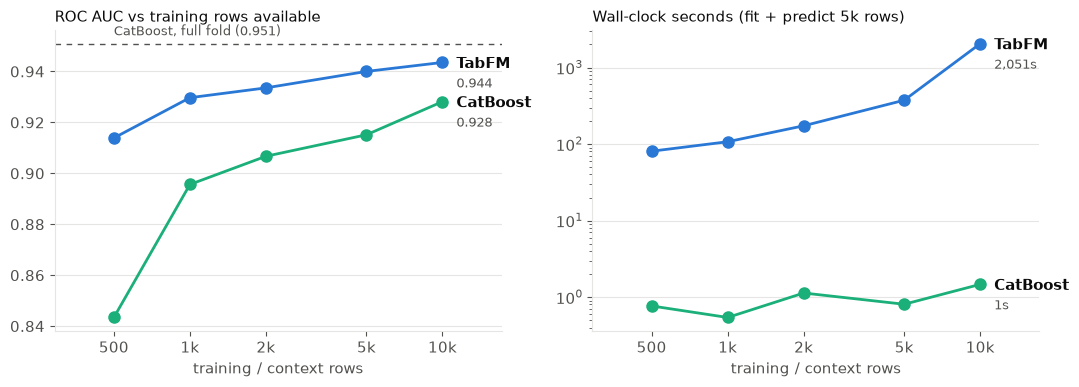

In [5]:
cb_full_raw = grid[(grid['model'] == 'CatBoost') & (grid['features'] == 'raw')
                   & (grid['train_rows'] > 100000)]['auc'].iloc[0]

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, metric, fmt, title in [
    (axes[0], 'auc', '{:.3f}', 'ROC AUC vs training rows available'),
    (axes[1], 'seconds', '{:,.0f}s', 'Wall-clock seconds (fit + predict 5k rows)'),
]:
    ax.set_axisbelow(True)
    ax.grid(axis='y', color=GRID, linewidth=0.8)
    for model, c in COLOR.items():
        d_ = sweep[sweep['model'] == model]
        ax.plot(d_['n_rows'], d_[metric], color=c, linewidth=2, marker='o', markersize=8)
        last = d_.iloc[-1]
        ax.annotate(model, (last['n_rows'], last[metric]), textcoords='offset points',
                    xytext=(10, -4), color=INK, fontweight='bold')
        ax.annotate(fmt.format(last[metric]), (last['n_rows'], last[metric]),
                    textcoords='offset points', xytext=(10, -18), color=INK2, fontsize=9)
    ax.set_xscale('log')
    ax.set_xticks(ex.SWEEP_CTX, [f'{n/1000:g}k' if n >= 1000 else str(n) for n in ex.SWEEP_CTX])
    ax.minorticks_off()
    ax.set_xlabel('training / context rows')
    ax.set_title(title, loc='left', fontsize=11)
    ax.margins(x=0.18)

axes[0].axhline(cb_full_raw, color=INK2, linewidth=1, linestyle=(0, (4, 4)))
axes[0].annotate(f'CatBoost, full fold ({cb_full_raw:.3f})', (ex.SWEEP_CTX[0], cb_full_raw),
                 textcoords='offset points', xytext=(0, 6), color=INK2, fontsize=9)
axes[1].set_yscale('log')
plt.tight_layout()
plt.show()

## Takeaways

1. **Zero-shot TabFM dominates whenever rows are scarce.** At every matched row budget it beats
   CatBoost by a wide margin: +7.1 AUC points at 500 rows (0.914 vs 0.843), +2.5 at 5k
   (0.940 vs 0.915). With just 1k in-context rows it already outperforms CatBoost trained on 10k.
   Google's pitch - no training, no tuning, no feature engineering - holds up on data it has
   never seen.

2. **Scale still wins.** CatBoost trained on the full fold (~351k rows) reaches 0.951 with zero
   feature engineering, ahead of the best TabFM configuration (0.944 at 10k rows). TabFM's ceiling
   is its context: it simply cannot ingest the other 340k rows.

3. **Feature engineering did not help TabFM - it hurt.** At 2k rows, raw columns scored 0.934 vs
   0.931 for the 104-column engineered set, at ~32x the inference cost (TabFM's compute scales
   roughly linearly with column count). The alternating row/column attention appears to learn the
   interactions itself; hand-built features mostly dilute the context. Even for CatBoost, the
   engineered pipeline only matters with lots of rows - and on this eval sample the tuned
   engineered full model (0.950) is statistically tied with raw full (0.951; eval SE is ~0.003).

4. **"No training" is not "no compute."** TabFM inference cost grows superlinearly with context:
   ~6 min at 5k rows, ~34 min at 10k, ~93 min for 2k rows x 104 columns (M2 Max, MPS, 8 ensemble
   members). CatBoost trains on the full 351k rows in 1-3 minutes on CPU. At this dataset size the
   GBDT is operationally far cheaper per prediction batch.

**Verdict:** for small tables (roughly <10k rows) TabFM is a genuinely free lunch - better accuracy
than a tuned GBDT with zero effort. Once data is abundant, a plain GBDT on raw columns is both more
accurate and orders of magnitude cheaper. The most surprising result is #3: against a tabular
foundation model, the feature-engineering playbook may be obsolete.